In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

from funcoes_monitoramento import (
    prepare_week_columns,
    plot_mix_and_volume,
)

In [31]:
from funcoes_escoragem import *

In [32]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base

In [33]:
df_blend4_dev = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv").drop(columns=["city_pc4_mais_100_contratos__pc_categorias"])
df_blend4_dev["safra"] = df_blend4_dev["requested_at"].astype(str).str[:7]
# df_blend4_dev = df_blend4_dev[df_blend4_dev["agency_pc4_mais_100_contratos__pc_categorias"]!=0]
# df_blend4_dev = df_blend4_dev[df_blend4_dev["safra"]!="2026-06"]
df_blend4_dev = df_blend4_dev[df_blend4_dev["income"]>0]
df_blend4_dev["request_imovel_codigo_cidade_ibge"] = (pd.to_numeric(df_blend4_dev["request_imovel_codigo_cidade_ibge"], errors="coerce").astype("Int64"))
df_blend4_dev["request_imobiliariaId"] = (pd.to_numeric(df_blend4_dev["request_imobiliariaId"], errors="coerce").astype("Int64"))
df_blend4_dev = df_blend4_dev[df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4", "BLEND_4"])]
# df_blend4_dev = df_blend4_dev[df_blend4_dev["requested_at"]>= "2026-07-05"]
df_blend4_dev

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4,safra
0,14392885771,4131211,2026-06-04,2026-06-04,1,NI,BLEND3_3,5899338,32,14392885771,...,0.0,2.150937,0.000000,-0.844994,0.518840,481.0,A,D,7.B,2026-06
1,47697497832,4174216,2026-05-26,2026-05-26,1,E,BLEND3_3,5850339,33,47697497832,...,8.0,0.125185,0.000000,0.551021,0.592440,408.0,C,E,9.D+,2026-05
2,7013437379,4175026,2026-05-26,2026-05-26,1,Z,BLEND3_3,5851327,33,7013437379,...,1.0,1.153340,0.101459,0.882277,0.610756,389.0,D,E,10.D,2026-05
3,9620425448,4175994,2026-05-26,2026-05-26,1,B,BLEND3_3,5852494,33,9620425448,...,2.0,0.528269,0.000000,0.000000,0.517874,482.0,A,D,7.B,2026-05
4,13362189679,4179391,2026-05-27,2026-05-27,1,NI,BLEND3_3,5856793,33,13362189679,...,5.0,0.809205,0.000000,0.000000,0.546987,453.0,B,E,8.C,2026-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348435,58809704851,4515666,2026-08-14,2026-08-14,1,Z,BLEND3_4,6272827,33,58809704851,...,6.0,0.452325,0.000000,0.766126,0.592774,407.0,D,E,10.D,2026-08
348436,37080924812,4515857,2026-08-14,2026-08-14,1,NI,BLEND_4,6273074,31,37080924812,...,0.0,-0.109947,0.000000,-0.617386,0.207912,792.0,A,A,1.A+,2026-08
348437,29114265842,4516818,2026-08-15,2026-08-15,1,NI,BLEND3_4,6274240,31,29114265842,...,1.0,-0.801848,0.000000,0.294421,0.509791,490.0,A,A,7.B,2026-08
348438,47831376844,4517743,2026-08-16,2026-08-16,1,NI,BLEND3_4,6275424,33,47831376844,...,0.0,2.421539,0.000000,-0.534513,0.548726,451.0,B,E,8.C,2026-08


## Cidade IBGE (BLEND_4)

`request_imovel_codigo_cidade_ibge` continua nulo em BLEND_4. A cidade corrigida vem de CredPago em `id_cidade_ibge` (`df_vars_faltantes_pc.parquet`). Onde essa coluna vier vazia, o fallback é o campo da request (BLEND3).

In [34]:
def read_parquet_safe(path: Path) -> pd.DataFrame:
    try:
        return pd.read_parquet(path)
    except (TypeError, ValueError):
        import pyarrow.parquet as pq
        return pq.read_table(path).replace_schema_metadata(None).to_pandas()


vars_city = read_parquet_safe(ANALYTICS_DIR / "df_vars_faltantes_pc.parquet")[
    ["contract_id", "id_cidade_ibge"]
].drop_duplicates("contract_id")
vars_city["contract_id"] = pd.to_numeric(vars_city["contract_id"], errors="coerce").astype("Int64")
vars_city["id_cidade_ibge"] = pd.to_numeric(vars_city["id_cidade_ibge"], errors="coerce").astype("Int64")

if "id_cidade_ibge" in df_blend4_dev.columns:
    df_blend4_dev = df_blend4_dev.drop(columns=["id_cidade_ibge"])

df_blend4_dev = df_blend4_dev.merge(vars_city, on="contract_id", how="left")
n_from_credpago = df_blend4_dev["id_cidade_ibge"].notna().sum()
df_blend4_dev["id_cidade_ibge"] = df_blend4_dev["id_cidade_ibge"].fillna(
    df_blend4_dev["request_imovel_codigo_cidade_ibge"]
)
df_blend4_dev["id_cidade_ibge"] = (
    pd.to_numeric(df_blend4_dev["id_cidade_ibge"], errors="coerce").astype("Int64")
)

print(f"id_cidade_ibge preenchido via CredPago: {n_from_credpago:,}")
print("Preenchimento de id_cidade_ibge por message_decisao:")
display(
    df_blend4_dev.assign(city_null=df_blend4_dev["id_cidade_ibge"].isna())
    .groupby("message_decisao")["city_null"]
    .agg(n="size", n_null="sum", pct_null="mean")
    .assign(pct_null=lambda d: (d["pct_null"] * 100).round(1))
)
df_blend4_dev[["contract_id", "message_decisao", "request_imovel_codigo_cidade_ibge", "id_cidade_ibge"]].head()

id_cidade_ibge preenchido via CredPago: 264,732
Preenchimento de id_cidade_ibge por message_decisao:


,n,n_null,pct_null
message_decisao,,,
BLEND3_3,189344,0,0.0
BLEND3_4,29639,0,0.0
BLEND_4,45759,1,0.0


,contract_id,message_decisao,request_imovel_codigo_cidade_ibge,id_cidade_ibge
0,4131211,BLEND3_3,4202008,4202008
1,4174216,BLEND3_3,3543402,3543402
2,4175026,BLEND3_3,2304400,2304400
3,4175994,BLEND3_3,3529302,3529302
4,4179391,BLEND3_3,3104007,3104007


Join de `id_cidade_ibge` já aplicado em `df_blend4_dev`. A análise de mix usa essa coluna.

In [35]:
print("Colunas de cidade em df_blend4_dev:")
display(
    df_blend4_dev[["contract_id", "message_decisao", "request_imovel_codigo_cidade_ibge", "id_cidade_ibge"]]
    .head()
)

Colunas de cidade em df_blend4_dev:


,contract_id,message_decisao,request_imovel_codigo_cidade_ibge,id_cidade_ibge
0,4131211,BLEND3_3,4202008,4202008
1,4174216,BLEND3_3,3543402,3543402
2,4175026,BLEND3_3,2304400,2304400
3,4175994,BLEND3_3,3529302,3529302
4,4179391,BLEND3_3,3104007,3104007


In [36]:
# df_blend4_dev already has id_cidade_ibge from the CredPago join above.

## Preparação

Semana = domingo a sábado (`year_week` = domingo). `BLEND3` junta `BLEND3_3` e `BLEND3_4`. A última semana incompleta entra no volume e sai das comparações early vs late.

In [37]:
TOP_N_MIX = 12
N_COMPARE_WEEKS = 3
MIN_WEEK_N = 300
MIN_ENTITY_LATE_N = 30
TOP_N_RANK = 20
TOP_N_GAINERS = 12
OTHER_LABEL = "Outros"

df_mix = prepare_week_columns(df_blend4_dev, date_col="requested_at")
df_mix["modelo"] = np.where(
    df_mix["message_decisao"].isin(["BLEND3_3", "BLEND3_4"]),
    "BLEND3",
    df_mix["message_decisao"],
)

max_date = df_mix["requested_at"].max().normalize()
df_mix["week_end"] = df_mix["week_start"] + pd.Timedelta(days=6)
df_mix["week_completa"] = df_mix["week_end"] <= max_date

week_order = (
    df_mix[["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)
complete_weeks = (
    df_mix.loc[df_mix["week_completa"], ["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)

print(f"Linhas: {len(df_mix):,}")
print(f"Período: {df_mix['requested_at'].min().date()} → {df_mix['requested_at'].max().date()}")
print(f"Semanas (dom–sáb): {week_order[0]} → {week_order[-1]} | n={len(week_order)}")
print(f"Semanas completas: {complete_weeks[0]} → {complete_weeks[-1]} | n={len(complete_weeks)}")
print("\nVolume por message_decisao:")
display(df_mix["message_decisao"].value_counts(dropna=False).to_frame("n"))
print("BLEND3 = BLEND3_3 + BLEND3_4")
display(df_mix["modelo"].value_counts().to_frame("n"))

Linhas: 264,742
Período: 2026-05-26 → 2026-08-17
Semanas (dom–sáb): 2026-05-24 → 2026-08-16 | n=13
Semanas completas: 2026-05-24 → 2026-08-09 | n=12

Volume por message_decisao:


,n
message_decisao,
BLEND3_3,189344
BLEND_4,45759
BLEND3_4,29639


BLEND3 = BLEND3_3 + BLEND3_4


,n
modelo,
BLEND3,218983
BLEND_4,45759


In [38]:
def _ibge_uf(item: dict) -> str:
    micro = item.get("microrregiao") or {}
    meso = micro.get("mesorregiao") or {}
    uf = (meso.get("UF") or {}).get("sigla")
    if uf:
        return uf
    imediata = item.get("regiao-imediata") or {}
    intermediaria = imediata.get("regiao-intermediaria") or {}
    return (intermediaria.get("UF") or {}).get("sigla") or ""


def load_ibge_city_names() -> dict:
    """Map IBGE municipality code -> 'City/UF'."""
    url = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        mapping = {}
        for item in response.json():
            uf = _ibge_uf(item)
            label = f"{item['nome']}/{uf}" if uf else item["nome"]
            mapping[int(item["id"])] = label
        return mapping
    except Exception as exc:
        print(f"Não foi possível carregar nomes IBGE ({exc}). Usando só o código.")
        return {}


def label_city(code, city_names: dict) -> str:
    if pd.isna(code):
        return "NA"
    code_int = int(code)
    name = city_names.get(code_int)
    return f"{name} ({code_int})" if name else str(code_int)


def label_agency(agency_id) -> str:
    if pd.isna(agency_id):
        return "NA"
    return str(int(agency_id))


def valid_weeks(df: pd.DataFrame, min_n: int = MIN_WEEK_N) -> list:
    counts = (
        df.loc[df["week_completa"]]
        .groupby("year_week")
        .size()
        .reindex(complete_weeks, fill_value=0)
    )
    return [week for week in complete_weeks if counts.get(week, 0) >= min_n]


def compare_windows(weeks: list, n: int = N_COMPARE_WEEKS):
    if len(weeks) < 2:
        return weeks, weeks
    n_use = min(n, max(1, len(weeks) // 2))
    return weeks[:n_use], weeks[-n_use:]


def weekly_share_table(df: pd.DataFrame, entity_col: str) -> pd.DataFrame:
    work = df.dropna(subset=[entity_col]).copy()
    if work.empty:
        return pd.DataFrame()
    share = (
        pd.crosstab(work["year_week"], work[entity_col], normalize="index")
        .mul(100)
        .reindex(week_order)
        .fillna(0)
    )
    return share


def weekly_volume(df: pd.DataFrame) -> pd.Series:
    return df.groupby("year_week").size().reindex(week_order, fill_value=0)


def collapse_to_top(df: pd.DataFrame, entity_col: str, top_n: int = TOP_N_MIX):
    work = df.dropna(subset=[entity_col]).copy()
    if work.empty:
        return work, []
    top_values = work[entity_col].value_counts().head(top_n).index.tolist()
    work[entity_col] = work[entity_col].where(
        work[entity_col].isin(top_values), OTHER_LABEL
    )
    return work, top_values


def mix_color_map(categories) -> dict:
    palette = list(plt.cm.tab20.colors)
    colors = {}
    cat_list = [c for c in categories if c != OTHER_LABEL]
    for i, category in enumerate(cat_list):
        colors[str(category)] = palette[i % len(palette)]
    if OTHER_LABEL in categories:
        colors[OTHER_LABEL] = "#94A3B8"
    return colors


def plot_top_mix(df: pd.DataFrame, entity_col: str, title: str, legend_title: str):
    work, top_values = collapse_to_top(df, entity_col)
    if work.empty:
        print(f"[skip] Sem dados para: {title}")
        return
    pct_df = (
        pd.crosstab(work["year_week"], work[entity_col], normalize="index")
        .mul(100)
        .reindex(week_order)
        .fillna(0)
    )
    volume = weekly_volume(work)
    category_order = [c for c in top_values if c in pct_df.columns] + (
        [OTHER_LABEL] if OTHER_LABEL in pct_df.columns else []
    )
    plot_mix_and_volume(
        pct_df,
        volume,
        title=title,
        xlabel="Semana",
        category_order=category_order,
        color_map=mix_color_map(category_order),
        legend_title=legend_title,
        min_label_pct=3.0,
        figsize=(14, 8),
    )
    plt.show()


def share_shift_table(
    df: pd.DataFrame,
    entity_col: str,
    early_weeks: list,
    late_weeks: list,
    label_fn,
) -> pd.DataFrame:
    work = df.dropna(subset=[entity_col]).copy()
    early = work[work["year_week"].isin(early_weeks)]
    late = work[work["year_week"].isin(late_weeks)]
    if early.empty or late.empty:
        return pd.DataFrame()

    early_n = early[entity_col].value_counts()
    late_n = late[entity_col].value_counts()
    early_share = early_n.div(len(early)).mul(100)
    late_share = late_n.div(len(late)).mul(100)

    entities = early_n.index.union(late_n.index)
    out = pd.DataFrame({"entity": entities})
    out["n_early"] = out["entity"].map(early_n).fillna(0).astype(int)
    out["n_late"] = out["entity"].map(late_n).fillna(0).astype(int)
    out["share_early_pct"] = out["entity"].map(early_share).fillna(0)
    out["share_late_pct"] = out["entity"].map(late_share).fillna(0)
    out["delta_pp"] = out["share_late_pct"] - out["share_early_pct"]
    out["rank_early"] = out["share_early_pct"].rank(ascending=False, method="min").astype(int)
    out["rank_late"] = out["share_late_pct"].rank(ascending=False, method="min").astype(int)
    out["rank_gain"] = out["rank_early"] - out["rank_late"]
    out["entered_top"] = (out["rank_early"] > TOP_N_RANK) & (out["rank_late"] <= TOP_N_RANK)
    out["label"] = out["entity"].map(label_fn)
    out = out[out["n_late"] >= MIN_ENTITY_LATE_N].sort_values("delta_pp", ascending=False)
    return out.reset_index(drop=True)


def plot_share_lines(share_df: pd.DataFrame, entities: list, title: str, label_fn):
    if share_df.empty or not entities:
        print(f"[skip] Sem dados para: {title}")
        return
    cols = [e for e in entities if e in share_df.columns]
    if not cols:
        print(f"[skip] Sem dados para: {title}")
        return
    fig, ax = plt.subplots(figsize=(14, 5))
    palette = list(plt.cm.tab20.colors)
    for i, entity in enumerate(cols):
        ax.plot(
            share_df.index.astype(str),
            share_df[entity],
            marker="o",
            linewidth=2,
            label=label_fn(entity),
            color=palette[i % len(palette)],
        )
    ax.set_title(title)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Share (%)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_share_heatmap(share_df: pd.DataFrame, entities: list, title: str, label_fn):
    cols = [e for e in entities if e in share_df.columns]
    if share_df.empty or not cols:
        print(f"[skip] Sem dados para: {title}")
        return
    heat = share_df[cols].T
    heat.index = [label_fn(e) for e in cols]
    fig, ax = plt.subplots(figsize=(14, max(3.5, 0.4 * len(cols) + 1.5)))
    sns.heatmap(
        heat,
        ax=ax,
        cmap="YlOrRd",
        annot=True,
        fmt=".1f",
        linewidths=0.3,
        cbar_kws={"label": "Share (%)"},
    )
    ax.set_title(title)
    ax.set_xlabel("Semana")
    ax.set_ylabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_top10_concentration(df: pd.DataFrame, entity_col: str, title: str):
    work = df.dropna(subset=[entity_col])
    if work.empty:
        print(f"[skip] Sem dados para: {title}")
        return
    rows = []
    for week, group in work.groupby("year_week"):
        share = group[entity_col].value_counts(normalize=True).mul(100)
        rows.append({"year_week": week, "top10_share_pct": share.head(10).sum(), "n": len(group)})
    conc = pd.DataFrame(rows).set_index("year_week").reindex(week_order)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(conc.index.astype(str), conc["top10_share_pct"], marker="o", color="#0F766E")
    ax.set_title(title)
    ax.set_xlabel("Semana")
    ax.set_ylabel("Share top 10 (%)")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def show_shift(shift_df: pd.DataFrame, title: str, n: int = TOP_N_GAINERS):
    if shift_df.empty:
        print(f"[skip] Sem dados para: {title}")
        return pd.DataFrame()
    cols = [
        "label", "n_early", "n_late", "share_early_pct", "share_late_pct",
        "delta_pp", "rank_early", "rank_late", "rank_gain", "entered_top",
    ]
    view = shift_df[cols].head(n).copy()
    view[["share_early_pct", "share_late_pct", "delta_pp"]] = view[
        ["share_early_pct", "share_late_pct", "delta_pp"]
    ].round(2)
    print(title)
    display(view)
    entered = shift_df[shift_df["entered_top"]][cols]
    if not entered.empty:
        print(f"Entraram no top {TOP_N_RANK} (não estavam antes):")
        display(entered.round(2))
    return view


city_names = load_ibge_city_names()
print(f"Nomes IBGE carregados: {len(city_names):,}")

Nomes IBGE carregados: 5,571


## Volume por semana e modelo

modelo,BLEND3,BLEND_4,total
year_week,,,
2026-05-24,16426,0,16426
2026-05-31,17101,0,17101
2026-06-07,21462,5,21467
2026-06-14,19734,16,19750
2026-06-21,19439,42,19481
2026-06-28,18853,421,19274
2026-07-05,19146,2476,21622
2026-07-12,19216,3997,23213
2026-07-19,19830,4192,24022


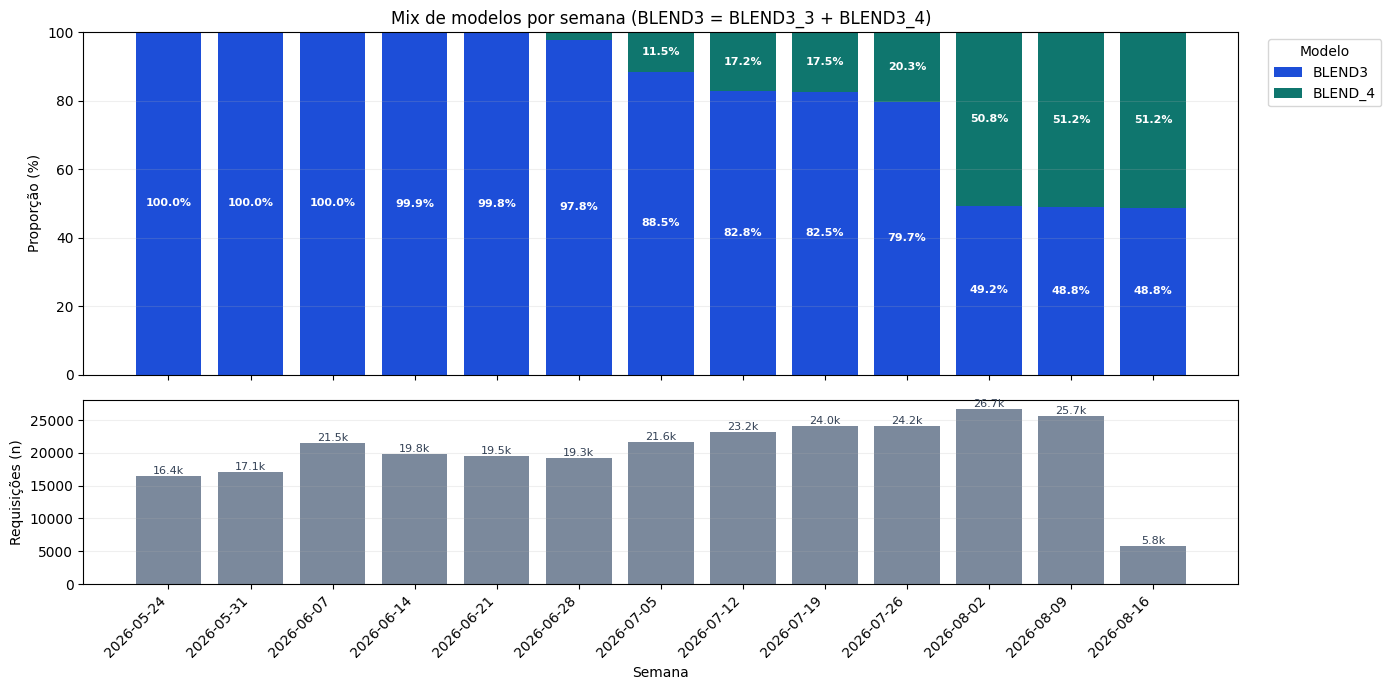

Cidade IBGE nula por modelo (id_cidade_ibge):


,n,n_null,pct_null
modelo,,,
BLEND3,218983,0,0.0
BLEND_4,45759,1,0.0


Preenchimento de id_cidade_ibge por semana e modelo (% nulo):


modelo,BLEND3,BLEND_4
year_week,,
2026-05-24,0.0,NaN
2026-05-31,0.0,NaN
2026-06-07,0.0,0.0
2026-06-14,0.0,0.0
2026-06-21,0.0,0.0
2026-06-28,0.0,0.0
2026-07-05,0.0,0.0
2026-07-12,0.0,0.0
2026-07-19,0.0,0.0


Imobiliária nula por modelo:


,n,n_null,pct_null
modelo,,,
BLEND3,218983,0,0.0
BLEND_4,45759,0,0.0


In [39]:
vol_week_model = (
    df_mix.groupby(["year_week", "modelo"])
    .size()
    .unstack(fill_value=0)
    .reindex(week_order)
)
vol_week_model["total"] = vol_week_model.sum(axis=1)
display(vol_week_model)

pct_model = vol_week_model.drop(columns="total")
pct_model = pct_model.div(pct_model.sum(axis=1).replace(0, np.nan), axis=0).mul(100).fillna(0)
plot_mix_and_volume(
    pct_model,
    vol_week_model["total"],
    title="Mix de modelos por semana (BLEND3 = BLEND3_3 + BLEND3_4)",
    xlabel="Semana",
    category_order=[c for c in ["BLEND3", "BLEND_4"] if c in pct_model.columns],
    color_map={"BLEND3": "#1D4ED8", "BLEND_4": "#0F766E"},
    legend_title="Modelo",
    min_label_pct=3.0,
    figsize=(14, 7),
)
plt.show()

print("Cidade IBGE nula por modelo (id_cidade_ibge):")
display(
    df_mix.assign(city_null=df_mix["id_cidade_ibge"].isna())
    .groupby("modelo")["city_null"]
    .agg(n="size", n_null="sum", pct_null="mean")
    .assign(pct_null=lambda d: (d["pct_null"] * 100).round(1))
)
print("Preenchimento de id_cidade_ibge por semana e modelo (% nulo):")
fill_week = (
    df_mix.assign(city_null=df_mix["id_cidade_ibge"].isna())
    .groupby(["year_week", "modelo"])["city_null"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(week_order)
    .round(1)
)
display(fill_week)
print("Imobiliária nula por modelo:")
display(
    df_mix.assign(agency_null=df_mix["request_imobiliariaId"].isna())
    .groupby("modelo")["agency_null"]
    .agg(n="size", n_null="sum", pct_null="mean")
    .assign(pct_null=lambda d: (d["pct_null"] * 100).round(1))
)

## Mix de Cidades

Share semanal de `id_cidade_ibge` por modelo. Em BLEND_4 a coluna da request continua nula; a cidade vem do cruzamento CredPago. O preenchimento cai forte em agosto — a comparação early vs late do BLEND_4 usa só semanas com volume suficiente de cidade preenchida.

Linhas com cidade: 264,741 | cidades distintas: 1,085
Volume com cidade por modelo:


,n
modelo,
BLEND3,218983
BLEND_4,45758


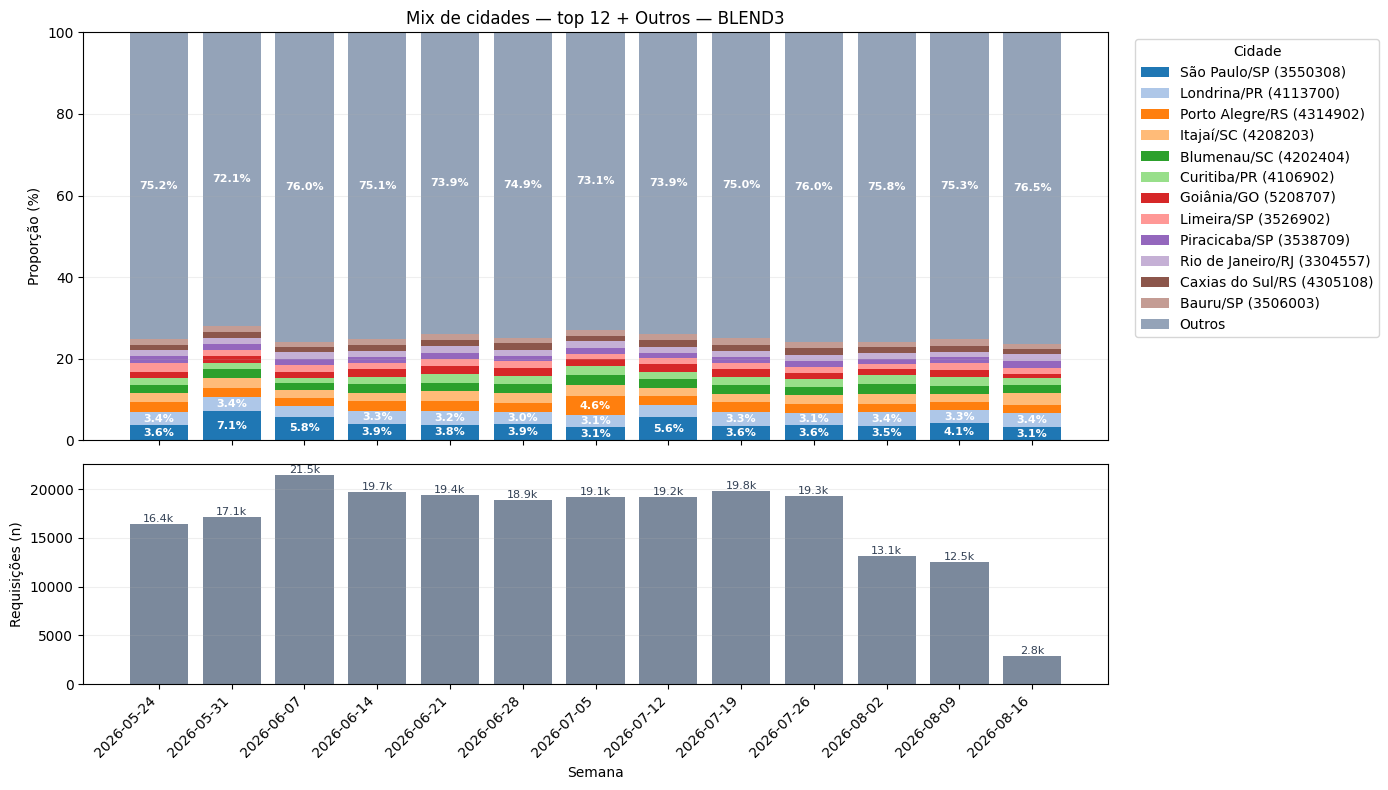

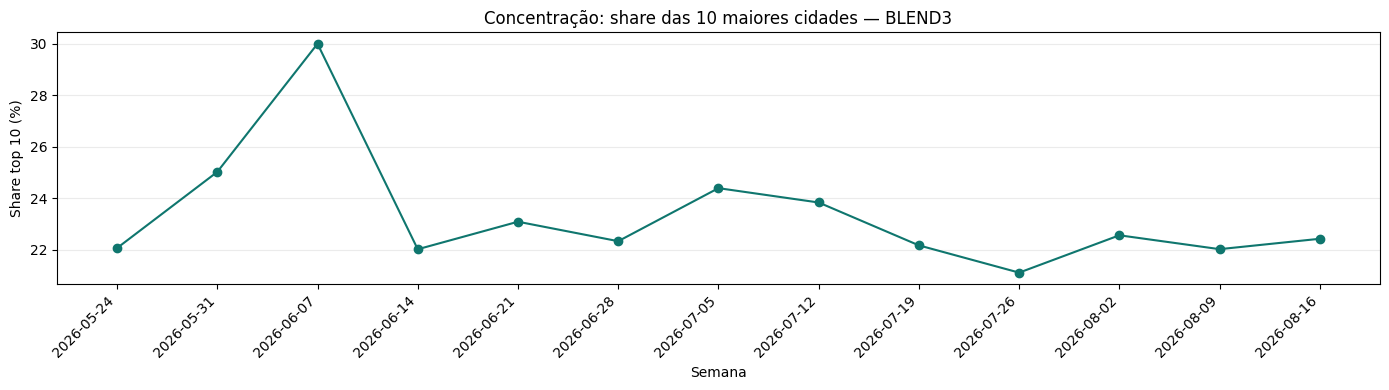

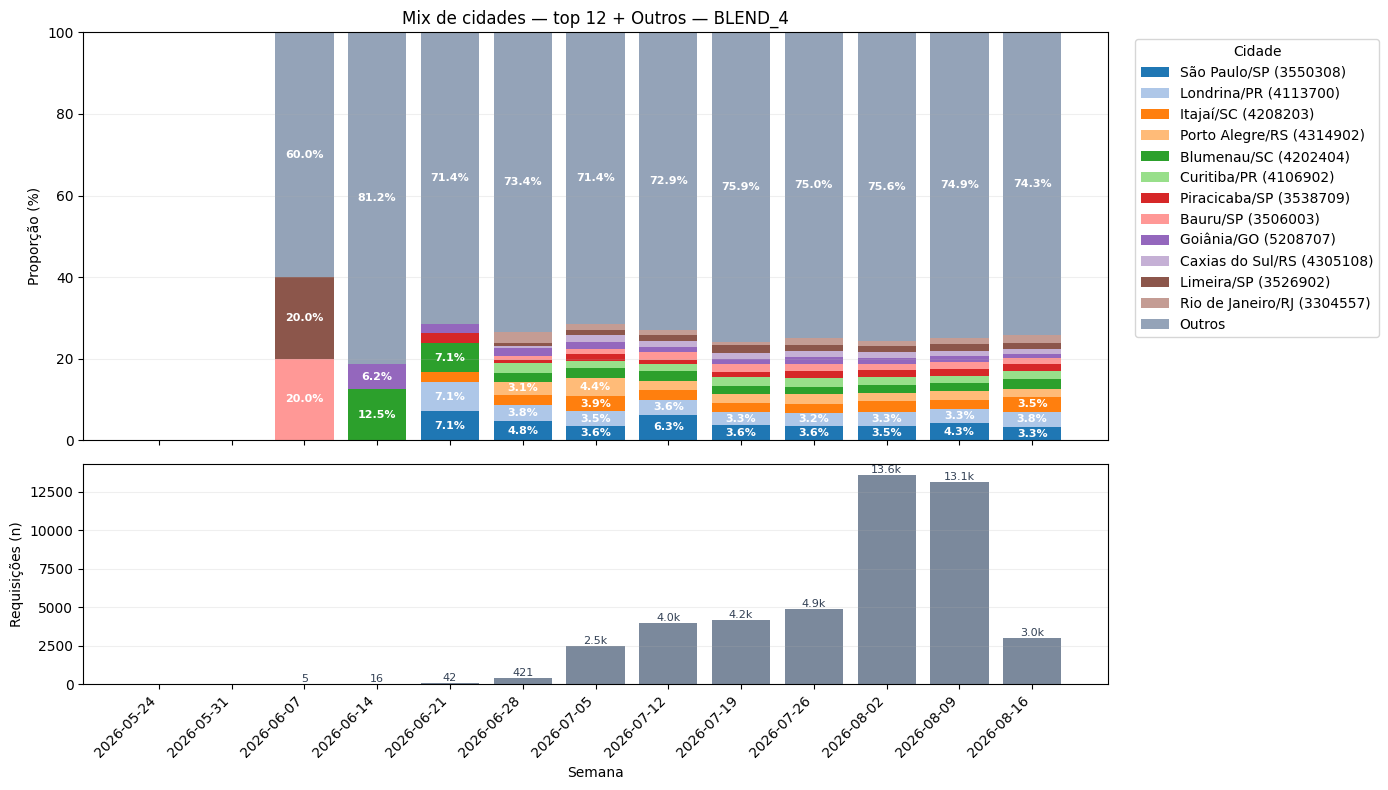

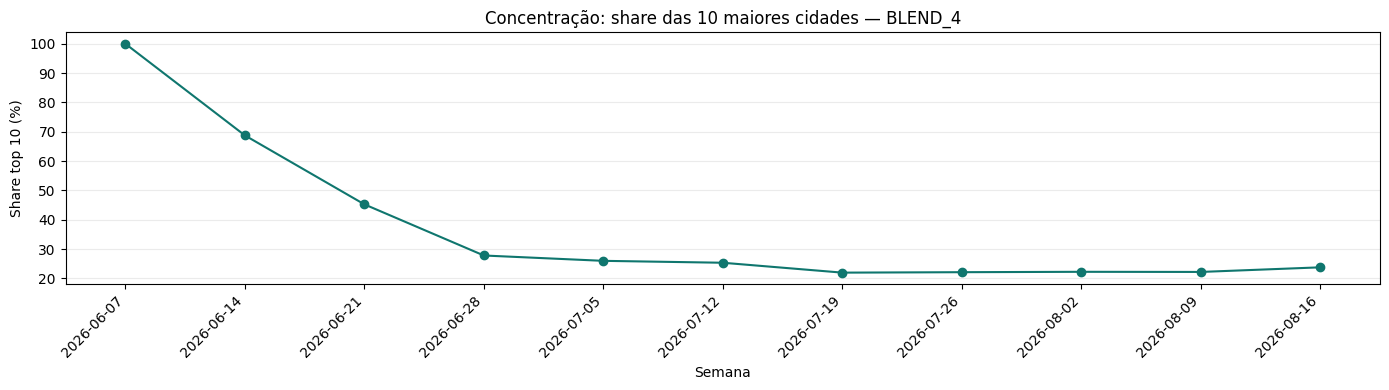

In [40]:
CITY_COL = "id_cidade_ibge"
city_label = lambda code: label_city(code, city_names)

df_city = df_mix.dropna(subset=[CITY_COL]).copy()
df_city["cidade"] = df_city[CITY_COL].map(city_label)

print(f"Linhas com cidade: {len(df_city):,} | cidades distintas: {df_city[CITY_COL].nunique():,}")
print("Volume com cidade por modelo:")
display(df_city.groupby("modelo").size().to_frame("n"))

for modelo, df_model in df_city.groupby("modelo"):
    plot_top_mix(
        df_model.assign(cidade_plot=df_model["cidade"]),
        entity_col="cidade_plot",
        title=f"Mix de cidades — top {TOP_N_MIX} + Outros — {modelo}",
        legend_title="Cidade",
    )
    plot_top10_concentration(
        df_model,
        entity_col=CITY_COL,
        title=f"Concentração: share das 10 maiores cidades — {modelo}",
    )

### Cidades que ganharam importância

Compara as primeiras vs as últimas semanas completas com volume suficiente. Destaque para quem subiu de share (pp) ou entrou no top 20.

BLEND3 | semanas válidas: 2026-05-24 → 2026-08-09
  early: ['2026-05-24', '2026-05-31', '2026-06-07'] | late: ['2026-07-26', '2026-08-02', '2026-08-09']
Cidades com maior ganho de share — BLEND3


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,Curitiba/PR (4106902),777,898,1.41,2.0,0.58,11,6,5,False
1,Paulínia/SP (3536505),25,281,0.05,0.63,0.58,256,49,207,False
2,Santa Maria/RS (4316907),570,610,1.04,1.36,0.32,19,13,6,False
3,Brusque/SC (4202909),339,377,0.62,0.84,0.22,48,31,17,False
4,Araçatuba/SP (3502804),382,402,0.69,0.89,0.2,37,26,11,False
5,Caxias do Sul/RS (4305108),710,670,1.29,1.49,0.2,13,9,4,False
6,Londrina/PR (4113700),1667,1443,3.03,3.21,0.18,3,2,1,False
7,Americana/SP (3501608),387,394,0.7,0.88,0.17,35,28,7,False
8,Campo Grande/MS (5002704),324,339,0.59,0.75,0.17,51,37,14,False
9,Belo Horizonte/MG (3106200),570,540,1.04,1.2,0.16,19,14,5,False


Entraram no top 20 (não estavam antes):


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
11,Florianópolis/SC (4205407),549,519,1.0,1.15,0.16,23,17,6,True


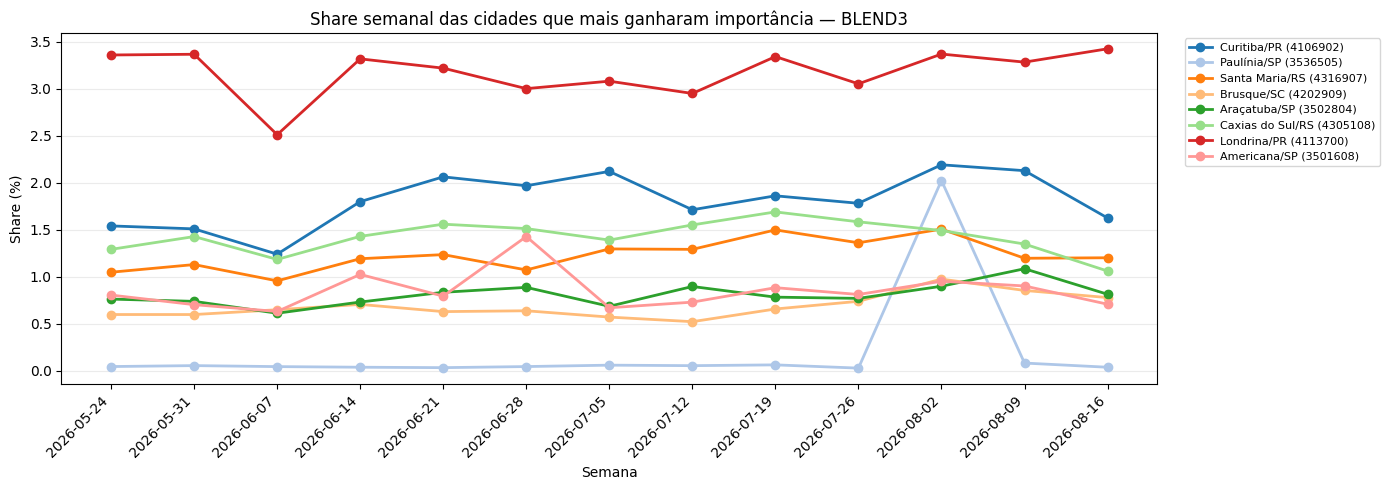

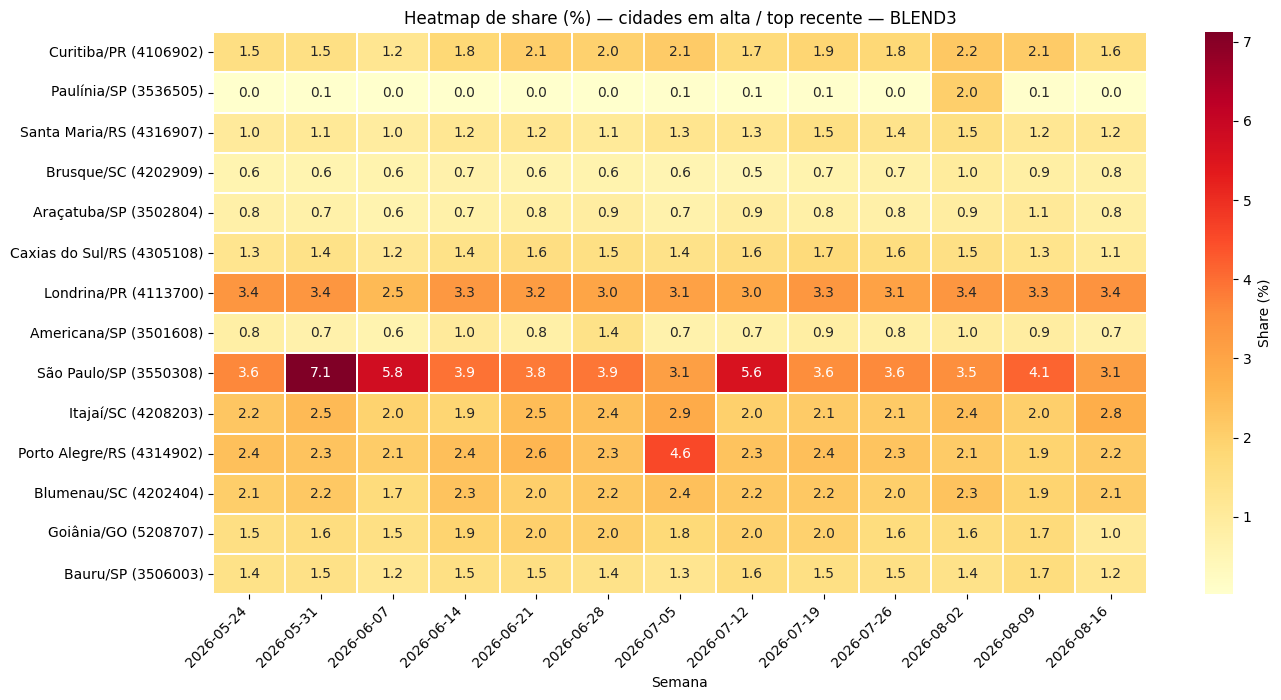

BLEND_4 | semanas válidas: 2026-06-28 → 2026-08-09
  early: ['2026-06-28', '2026-07-05', '2026-07-12'] | late: ['2026-07-26', '2026-08-02', '2026-08-09']
Cidades com maior ganho de share — BLEND_4


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,Paulínia/SP (3536505),6,271,0.09,0.86,0.77,179,27,152,False
1,Piracicaba/SP (3538709),85,542,1.23,1.71,0.48,14,7,7,False
2,Navegantes/SC (4211306),23,228,0.33,0.72,0.39,73,40,33,False
3,Taubaté/SP (3554102),24,208,0.35,0.66,0.31,71,47,24,False
4,São José do Rio Preto/SP (3549805),70,417,1.02,1.32,0.3,22,13,9,True
5,Palhoça/SC (4211900),35,256,0.51,0.81,0.3,52,31,21,False
6,Brusque/SC (4202909),48,311,0.7,0.98,0.29,42,20,22,True
7,Bento Gonçalves/RS (4302105),36,240,0.52,0.76,0.24,50,37,13,False
8,Limeira/SP (3526902),86,469,1.25,1.48,0.23,13,10,3,False
9,Fazenda Rio Grande/PR (4107652),19,156,0.28,0.49,0.22,84,60,24,False


Entraram no top 20 (não estavam antes):


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
4,São José do Rio Preto/SP (3549805),70,417,1.02,1.32,0.3,22,13,9,True
6,Brusque/SC (4202909),48,311,0.7,0.98,0.29,42,20,22,True


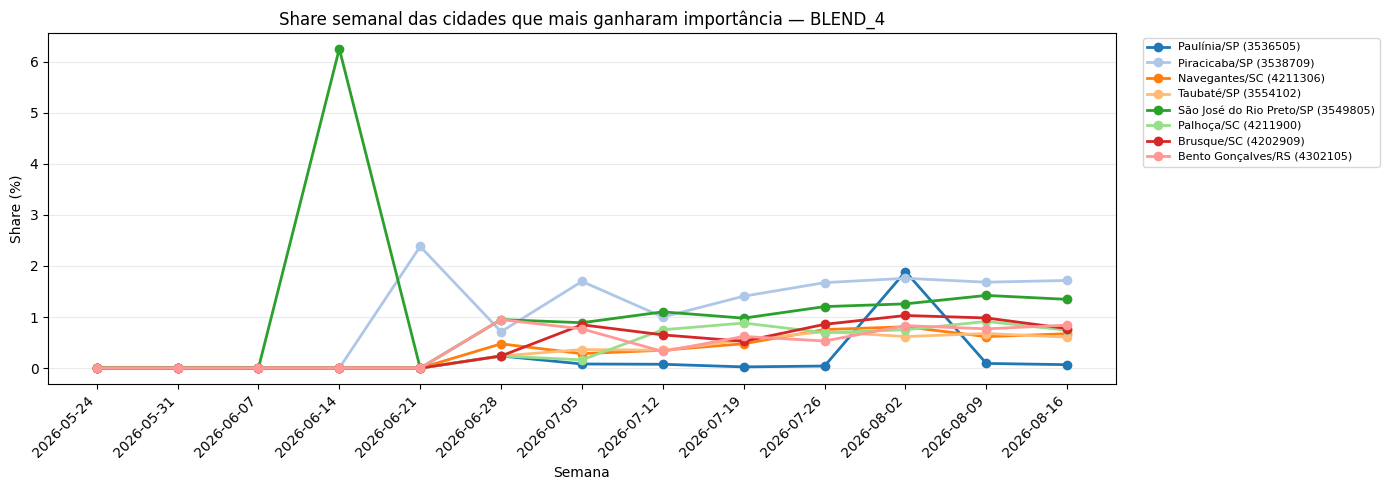

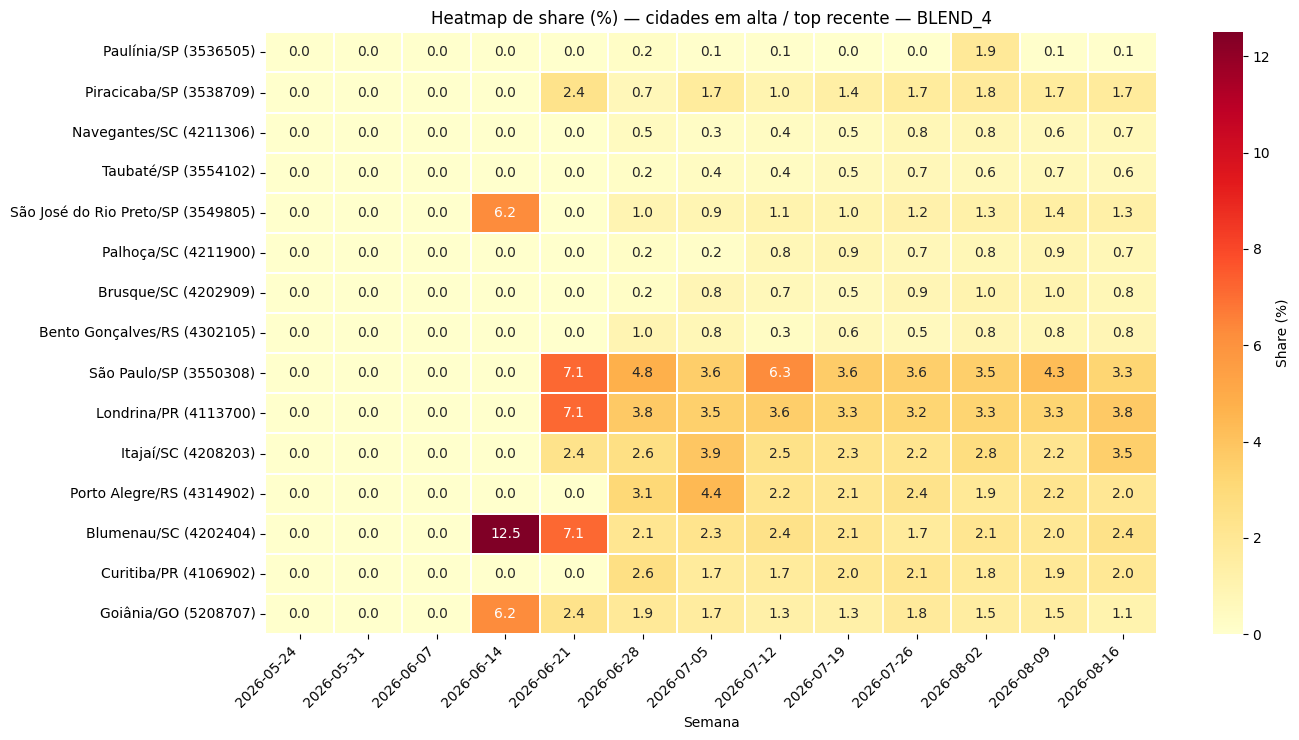

In [41]:
city_gainers = {}

for modelo, df_model in df_city.groupby("modelo"):
    weeks_ok = valid_weeks(df_model)
    early_weeks, late_weeks = compare_windows(weeks_ok)
    print(f"{modelo} | semanas válidas: {weeks_ok[0] if weeks_ok else '—'} → {weeks_ok[-1] if weeks_ok else '—'}")
    print(f"  early: {early_weeks} | late: {late_weeks}")

    shift = share_shift_table(
        df_model, CITY_COL, early_weeks, late_weeks, city_label
    )
    city_gainers[modelo] = shift
    show_shift(shift, f"Cidades com maior ganho de share — {modelo}")

    share_week = weekly_share_table(df_model, CITY_COL)
    risers = shift.head(TOP_N_GAINERS)["entity"].tolist()
    top_now = (
        df_model[df_model["year_week"].isin(late_weeks)][CITY_COL]
        .value_counts()
        .head(8)
        .index.tolist()
    )
    plot_entities = list(dict.fromkeys(risers[:8] + top_now))
    plot_share_lines(
        share_week,
        risers[:8],
        title=f"Share semanal das cidades que mais ganharam importância — {modelo}",
        label_fn=city_label,
    )
    plot_share_heatmap(
        share_week,
        plot_entities,
        title=f"Heatmap de share (%) — cidades em alta / top recente — {modelo}",
        label_fn=city_label,
    )

### Comparação recente de cidades entre modelos

Top cidades nas semanas em que BLEND_4 tem `id_cidade_ibge` preenchido, vs BLEND3 no mesmo recorte.

In [42]:
blend4_city_weeks = valid_weeks(df_city[df_city["modelo"] == "BLEND_4"])
print(f"Semanas BLEND_4 com cidade suficiente: {blend4_city_weeks}")

if blend4_city_weeks:
    df_city_overlap = df_city[df_city["year_week"].isin(blend4_city_weeks)]
    city_rows = []
    for modelo, df_model in df_city_overlap.groupby("modelo"):
        counts = df_model[CITY_COL].value_counts()
        share = counts.div(len(df_model)).mul(100)
        city_rows.append(pd.DataFrame({
            "cidade": counts.index.map(city_label),
            "n": counts.values,
            "share_pct": share.values.round(2),
            "modelo": modelo,
        }).head(15))
    display(pd.concat(city_rows, ignore_index=True).sort_values(
        ["modelo", "share_pct"], ascending=[True, False]
    ))

    blend3_c = df_city_overlap[df_city_overlap["modelo"] == "BLEND3"]
    blend4_c = df_city_overlap[df_city_overlap["modelo"] == "BLEND_4"]
    if not blend3_c.empty and not blend4_c.empty:
        s3 = blend3_c[CITY_COL].value_counts(normalize=True).mul(100)
        s4 = blend4_c[CITY_COL].value_counts(normalize=True).mul(100)
        n3 = blend3_c[CITY_COL].value_counts()
        n4 = blend4_c[CITY_COL].value_counts()
        idx = s3.index.union(s4.index)
        compare_city = pd.DataFrame({
            "cidade": [city_label(i) for i in idx],
            "n_blend3": n3.reindex(idx).fillna(0).astype(int).values,
            "n_blend4": n4.reindex(idx).fillna(0).astype(int).values,
            "share_blend3_pct": s3.reindex(idx).fillna(0).values,
            "share_blend4_pct": s4.reindex(idx).fillna(0).values,
        })
        compare_city["delta_pp_blend4_vs_blend3"] = (
            compare_city["share_blend4_pct"] - compare_city["share_blend3_pct"]
        )
        compare_city = compare_city[compare_city["n_blend4"] >= MIN_ENTITY_LATE_N].sort_values(
            "delta_pp_blend4_vs_blend3", ascending=False
        )
        print("Cidades relativamente mais presentes em BLEND_4 do que em BLEND3 (semanas com cidade no BLEND_4):")
        display(compare_city.head(15).round(2))
else:
    print("[skip] BLEND_4 sem semanas com volume suficiente de id_cidade_ibge.")

Semanas BLEND_4 com cidade suficiente: ['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09']


,cidade,n,share_pct,modelo
0,São Paulo/SP (3550308),4797,3.93,BLEND3
1,Londrina/PR (4113700),3829,3.14,BLEND3
2,Porto Alegre/RS (4314902),3195,2.62,BLEND3
3,Itajaí/SC (4208203),2800,2.3,BLEND3
4,Blumenau/SC (4202404),2657,2.18,BLEND3
5,Curitiba/PR (4106902),2373,1.95,BLEND3
6,Goiânia/GO (5208707),2229,1.83,BLEND3
7,Caxias do Sul/RS (4305108),1854,1.52,BLEND3
8,Bauru/SP (3506003),1791,1.47,BLEND3
9,Rio de Janeiro/RJ (3304557),1769,1.45,BLEND3


Cidades relativamente mais presentes em BLEND_4 do que em BLEND3 (semanas com cidade no BLEND_4):


,cidade,n_blend3,n_blend4,share_blend3_pct,share_blend4_pct,delta_pp_blend4_vs_blend3
475,Paulínia/SP (3536505),322,278,0.26,0.65,0.39
523,São José do Rio Preto/SP (3549805),1222,528,1.0,1.24,0.23
714,Itajaí/SC (4208203),2800,1073,2.3,2.51,0.22
685,Brusque/SC (4202909),836,381,0.69,0.89,0.21
611,Londrina/PR (4113700),3829,1421,3.14,3.33,0.19
485,Piracicaba/SP (3538709),1760,686,1.44,1.61,0.16
517,Santos/SP (3548500),354,180,0.29,0.42,0.13
105,Belo Horizonte/MG (3106200),1306,510,1.07,1.19,0.12
538,Sumaré/SP (3552403),374,182,0.31,0.43,0.12
527,São Paulo/SP (3550308),4797,1729,3.93,4.05,0.11


## Mix de Imobiliárias

Share semanal de `request_imobiliariaId` por modelo. A cauda é longa (milhares de imobiliárias), então o stacked mostra top 12 + Outros e a leitura de mudança fica na tabela de ganho de share.

Linhas com imobiliária: 264,742 | imobiliárias distintas: 10,177


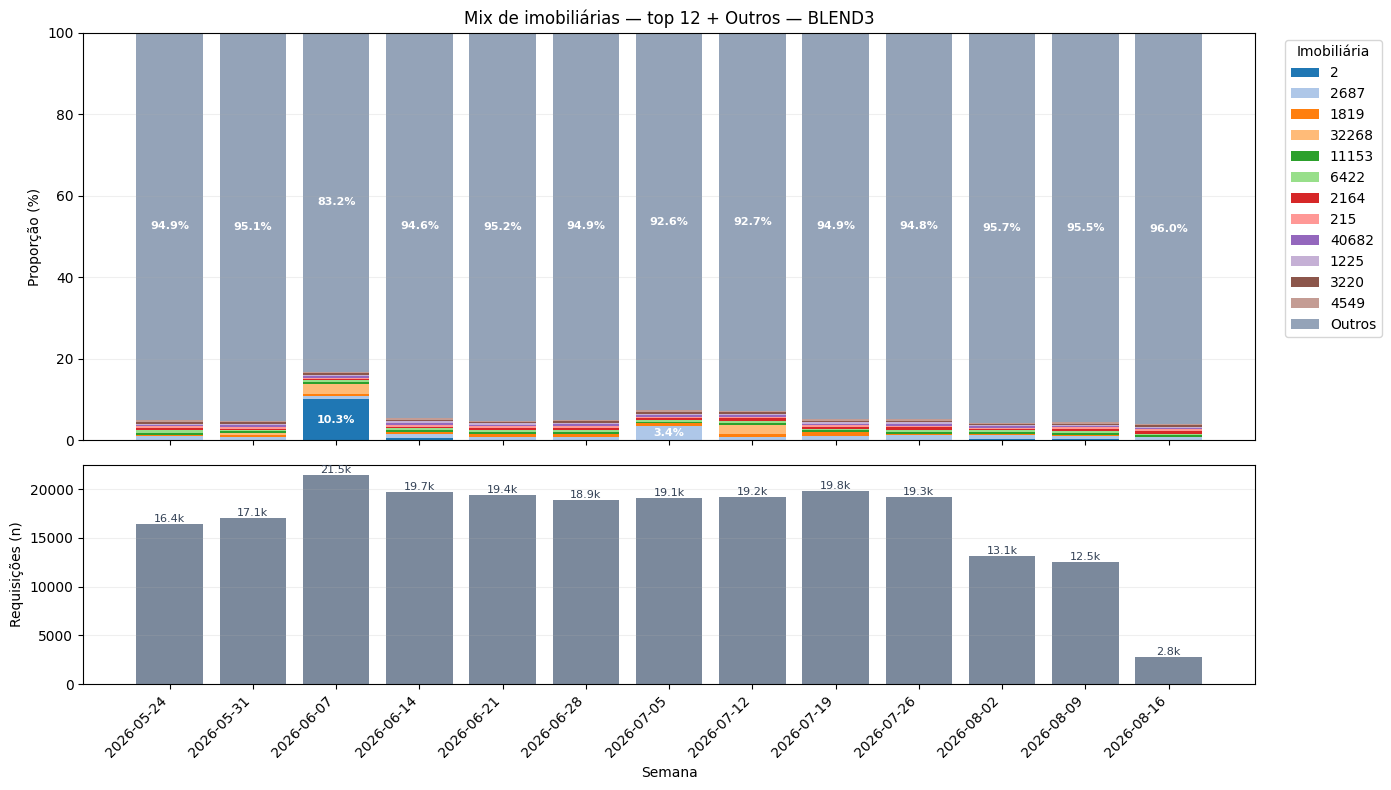

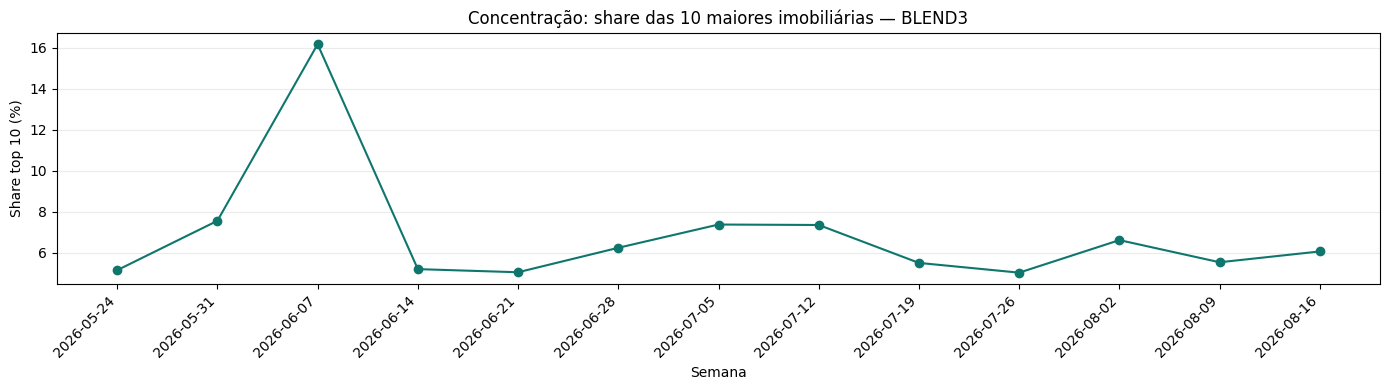

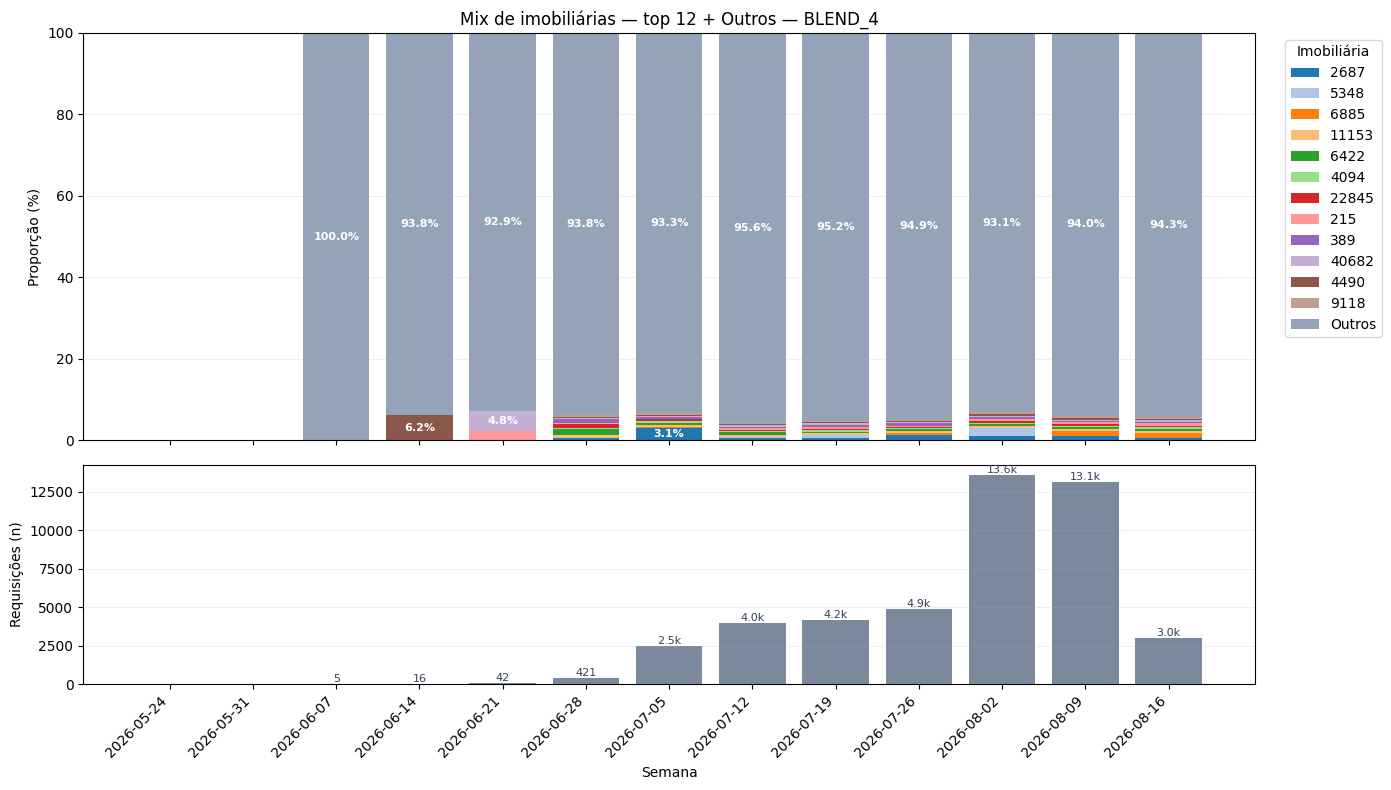

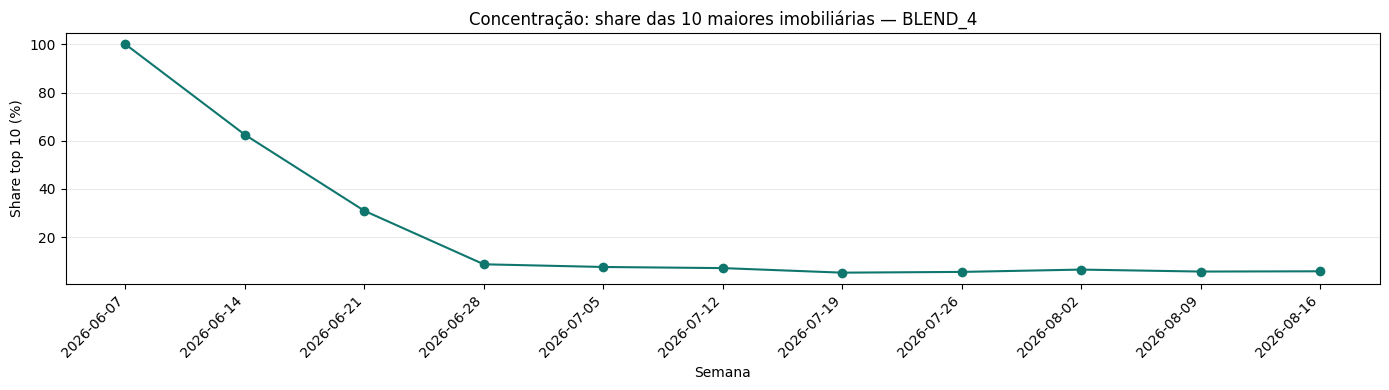

In [43]:
AGENCY_COL = "request_imobiliariaId"

df_agency = df_mix.dropna(subset=[AGENCY_COL]).copy()
print(
    f"Linhas com imobiliária: {len(df_agency):,} | "
    f"imobiliárias distintas: {df_agency[AGENCY_COL].nunique():,}"
)

for modelo, df_model in df_agency.groupby("modelo"):
    plot_top_mix(
        df_model.assign(imob_plot=df_model[AGENCY_COL].map(label_agency)),
        entity_col="imob_plot",
        title=f"Mix de imobiliárias — top {TOP_N_MIX} + Outros — {modelo}",
        legend_title="Imobiliária",
    )
    plot_top10_concentration(
        df_model,
        entity_col=AGENCY_COL,
        title=f"Concentração: share das 10 maiores imobiliárias — {modelo}",
    )

### Imobiliárias que ganharam importância

Mesma janela early vs late por modelo. Em BLEND_4 o volume só fica relevante a partir de julho — a comparação usa as primeiras semanas com volume suficiente.

BLEND3 | semanas válidas: 2026-05-24 → 2026-08-09
  early: ['2026-05-24', '2026-05-31', '2026-06-07'] | late: ['2026-07-26', '2026-08-02', '2026-08-09']
Imobiliárias com maior ganho de share — BLEND3


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,5348,24,289,0.04,0.64,0.6,440,2,438,True
1,6885,0,232,0.0,0.52,0.52,6217,3,6214,True
2,4881,5,118,0.01,0.26,0.25,2177,28,2149,False
3,51620,67,159,0.12,0.35,0.23,81,14,67,True
4,45829,82,164,0.15,0.36,0.22,59,11,48,True
5,2687,420,437,0.76,0.97,0.21,4,1,3,False
6,52181,23,86,0.04,0.19,0.15,456,43,413,False
7,25753,1,59,0.0,0.13,0.13,4624,79,4545,False
8,26609,81,120,0.15,0.27,0.12,60,26,34,False
9,23875,15,66,0.03,0.15,0.12,772,63,709,False


Entraram no top 20 (não estavam antes):


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,5348,24,289,0.04,0.64,0.6,440,2,438,True
1,6885,0,232,0.0,0.52,0.52,6217,3,6214,True
3,51620,67,159,0.12,0.35,0.23,81,14,67,True
4,45829,82,164,0.15,0.36,0.22,59,11,48,True
21,4094,155,159,0.28,0.35,0.07,22,14,8,True
72,33067,154,143,0.28,0.32,0.04,23,19,4,True


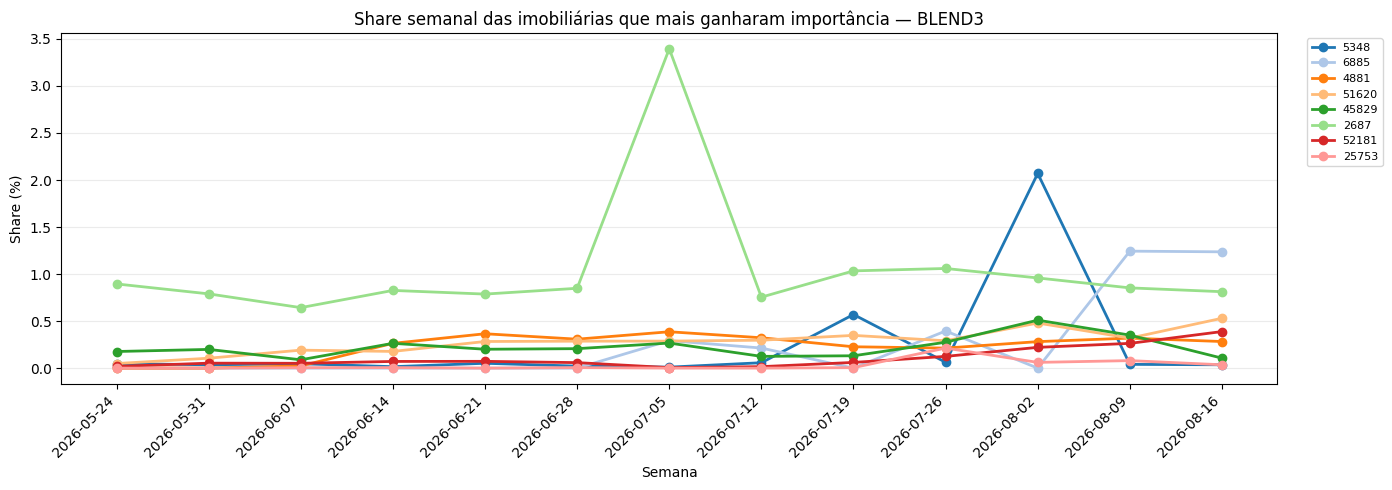

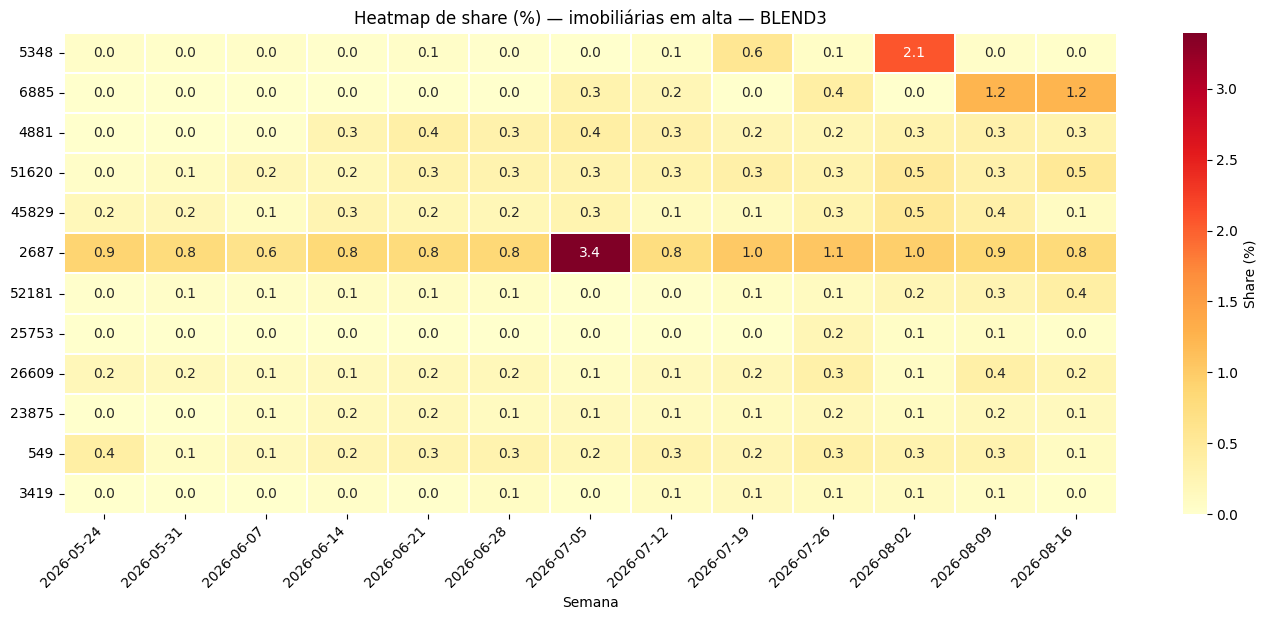

BLEND_4 | semanas válidas: 2026-06-28 → 2026-08-09
  early: ['2026-06-28', '2026-07-05', '2026-07-12'] | late: ['2026-07-26', '2026-08-02', '2026-08-09']
Imobiliárias com maior ganho de share — BLEND_4


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,5348,4,263,0.06,0.83,0.77,343,2,341,True
1,6885,11,198,0.16,0.63,0.47,61,3,58,True
2,52181,1,86,0.01,0.27,0.26,1282,25,1257,False
3,4490,17,141,0.25,0.45,0.2,26,6,20,True
4,26609,3,70,0.04,0.22,0.18,498,34,464,False
5,13380,12,111,0.17,0.35,0.18,47,16,31,True
6,45829,12,110,0.17,0.35,0.17,47,17,30,True
7,51620,15,122,0.22,0.39,0.17,33,11,22,True
8,25753,0,48,0.0,0.15,0.15,2596,62,2534,False
9,13554,7,78,0.1,0.25,0.15,142,28,114,False


Entraram no top 20 (não estavam antes):


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,5348,4,263,0.06,0.83,0.77,343,2,341,True
1,6885,11,198,0.16,0.63,0.47,61,3,58,True
3,4490,17,141,0.25,0.45,0.2,26,6,20,True
5,13380,12,111,0.17,0.35,0.18,47,16,31,True
6,45829,12,110,0.17,0.35,0.17,47,17,30,True
7,51620,15,122,0.22,0.39,0.17,33,11,22,True
12,923,14,105,0.2,0.33,0.13,38,18,20,True
24,33067,15,95,0.22,0.3,0.08,33,19,14,True


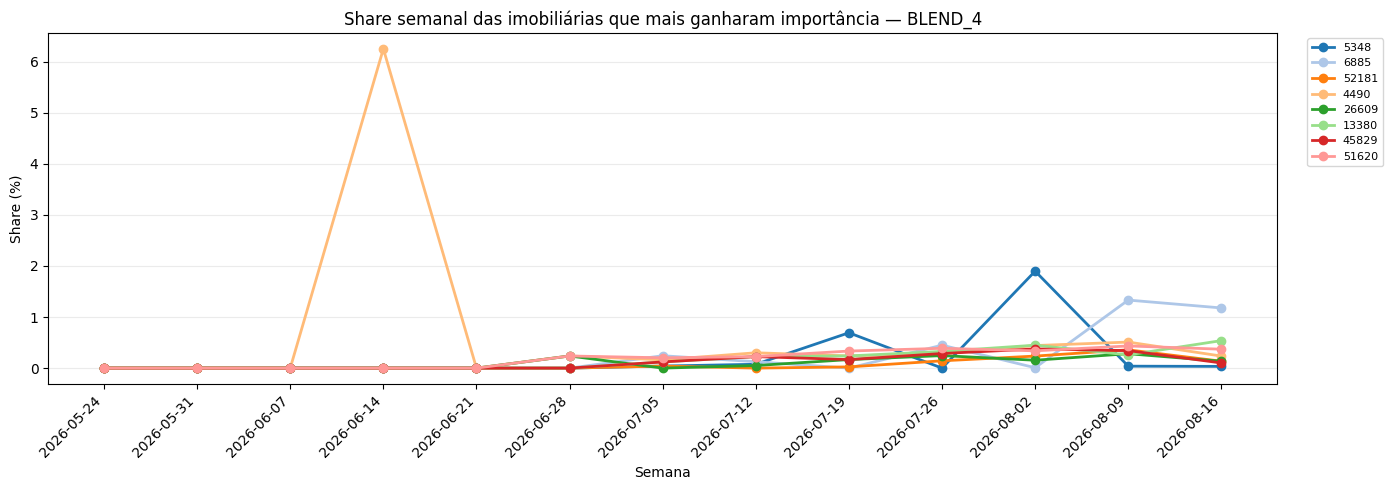

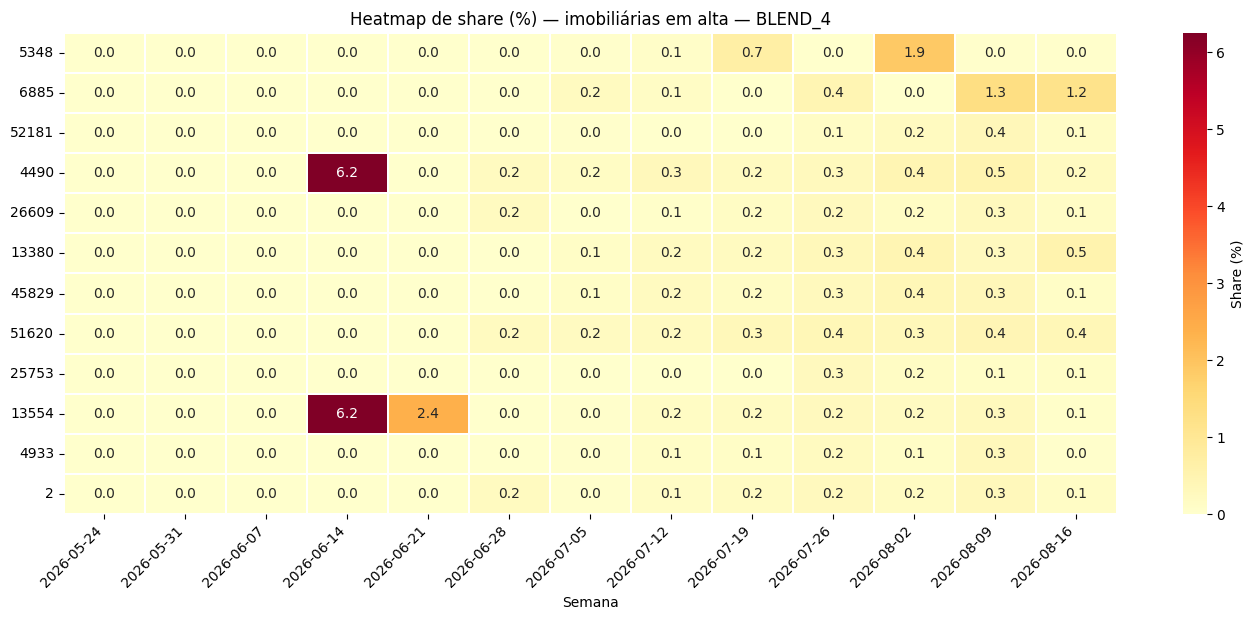

In [44]:
agency_gainers = {}

for modelo, df_model in df_agency.groupby("modelo"):
    weeks_ok = valid_weeks(df_model)
    early_weeks, late_weeks = compare_windows(weeks_ok)
    print(f"{modelo} | semanas válidas: {weeks_ok[0] if weeks_ok else '—'} → {weeks_ok[-1] if weeks_ok else '—'}")
    print(f"  early: {early_weeks} | late: {late_weeks}")

    shift = share_shift_table(
        df_model, AGENCY_COL, early_weeks, late_weeks, label_agency
    )
    agency_gainers[modelo] = shift
    show_shift(shift, f"Imobiliárias com maior ganho de share — {modelo}")

    share_week = weekly_share_table(df_model, AGENCY_COL)
    risers = shift.head(TOP_N_GAINERS)["entity"].tolist()
    plot_share_lines(
        share_week,
        risers[:8],
        title=f"Share semanal das imobiliárias que mais ganharam importância — {modelo}",
        label_fn=label_agency,
    )
    plot_share_heatmap(
        share_week,
        risers[:12],
        title=f"Heatmap de share (%) — imobiliárias em alta — {modelo}",
        label_fn=label_agency,
    )

### Comparação recente entre modelos

Top imobiliárias das últimas semanas completas em BLEND3 vs BLEND_4 — para ver se o modelo novo concentra em parceiros diferentes.

In [45]:
late_weeks_all = complete_weeks[-N_COMPARE_WEEKS:]
df_recent = df_agency[df_agency["year_week"].isin(late_weeks_all)]
print(f"Janela recente: {late_weeks_all}")

recent_rows = []
for modelo, df_model in df_recent.groupby("modelo"):
    counts = df_model[AGENCY_COL].value_counts()
    share = counts.div(len(df_model)).mul(100)
    tmp = pd.DataFrame({
        "imobiliaria": counts.index.map(label_agency),
        "n": counts.values,
        "share_pct": share.values.round(2),
        "modelo": modelo,
    }).head(15)
    recent_rows.append(tmp)

recent_top = pd.concat(recent_rows, ignore_index=True)
display(recent_top.sort_values(["modelo", "share_pct"], ascending=[True, False]))

# Agencies that are material in BLEND_4 but small in BLEND3 in the same window
blend3_recent = df_recent[df_recent["modelo"] == "BLEND3"]
blend4_recent = df_recent[df_recent["modelo"] == "BLEND_4"]
if not blend3_recent.empty and not blend4_recent.empty:
    s3 = blend3_recent[AGENCY_COL].value_counts(normalize=True).mul(100)
    s4 = blend4_recent[AGENCY_COL].value_counts(normalize=True).mul(100)
    n3 = blend3_recent[AGENCY_COL].value_counts()
    n4 = blend4_recent[AGENCY_COL].value_counts()
    idx = s3.index.union(s4.index)
    compare = pd.DataFrame({
        "imobiliaria": [label_agency(i) for i in idx],
        "n_blend3": n3.reindex(idx).fillna(0).astype(int).values,
        "n_blend4": n4.reindex(idx).fillna(0).astype(int).values,
        "share_blend3_pct": s3.reindex(idx).fillna(0).values,
        "share_blend4_pct": s4.reindex(idx).fillna(0).values,
    })
    compare["delta_pp_blend4_vs_blend3"] = compare["share_blend4_pct"] - compare["share_blend3_pct"]
    compare = compare[compare["n_blend4"] >= MIN_ENTITY_LATE_N].sort_values(
        "delta_pp_blend4_vs_blend3", ascending=False
    )
    print("Imobiliárias relativamente mais presentes em BLEND_4 do que em BLEND3 (janela recente):")
    display(compare.head(15).round(2))

Janela recente: ['2026-07-26', '2026-08-02', '2026-08-09']


,imobiliaria,n,share_pct,modelo
0,2687,437,0.97,BLEND3
1,5348,289,0.64,BLEND3
2,6885,232,0.52,BLEND3
3,6422,211,0.47,BLEND3
4,11153,211,0.47,BLEND3
5,2164,194,0.43,BLEND3
6,215,181,0.4,BLEND3
7,9118,179,0.4,BLEND3
8,4490,175,0.39,BLEND3
9,40682,168,0.37,BLEND3


Imobiliárias relativamente mais presentes em BLEND_4 do que em BLEND3 (janela recente):


,imobiliaria,n_blend3,n_blend4,share_blend3_pct,share_blend4_pct,delta_pp_blend4_vs_blend3
898,5348,289,263,0.64,0.83,0.19
2832,22845,117,133,0.26,0.42,0.16
565,2687,437,344,0.97,1.09,0.12
1054,6885,232,198,0.52,0.63,0.11
1312,9378,83,92,0.18,0.29,0.11
1814,13335,31,49,0.07,0.15,0.09
5750,50799,67,74,0.15,0.23,0.08
5908,52181,86,86,0.19,0.27,0.08
1317,9418,48,59,0.11,0.19,0.08
3584,29800,31,47,0.07,0.15,0.08


### Visão consolidada (BLEND3 + BLEND_4)

Mix do portfólio inteiro — útil para ver se a entrada do BLEND_4 deslocou o share de alguma imobiliária.

Cidades — consolidado (id_cidade_ibge)
early: ['2026-05-24', '2026-05-31', '2026-06-07'] | late: ['2026-07-26', '2026-08-02', '2026-08-09']
Cidades com maior ganho de share — consolidado


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,Paulínia/SP (3536505),25,552,0.05,0.72,0.68,256,41,215,False
1,Curitiba/PR (4106902),777,1502,1.41,1.96,0.55,11,6,5,False
2,Brusque/SC (4202909),339,688,0.62,0.9,0.28,48,25,23,False
3,Santa Maria/RS (4316907),570,1009,1.04,1.32,0.28,19,13,6,False
4,Londrina/PR (4113700),1667,2481,3.03,3.24,0.21,3,2,1,False
5,Caxias do Sul/RS (4305108),710,1137,1.29,1.48,0.19,13,10,3,False
6,Fazenda Rio Grande/PR (4107652),149,350,0.27,0.46,0.19,84,63,21,False
7,São José do Rio Preto/SP (3549805),570,933,1.04,1.22,0.18,19,14,5,False
8,Belo Horizonte/MG (3106200),570,931,1.04,1.22,0.18,19,15,4,False
9,Florianópolis/SC (4205407),549,888,1.0,1.16,0.16,23,19,4,True


Entraram no top 20 (não estavam antes):


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
9,Florianópolis/SC (4205407),549,888,1.0,1.16,0.16,23,19,4,True


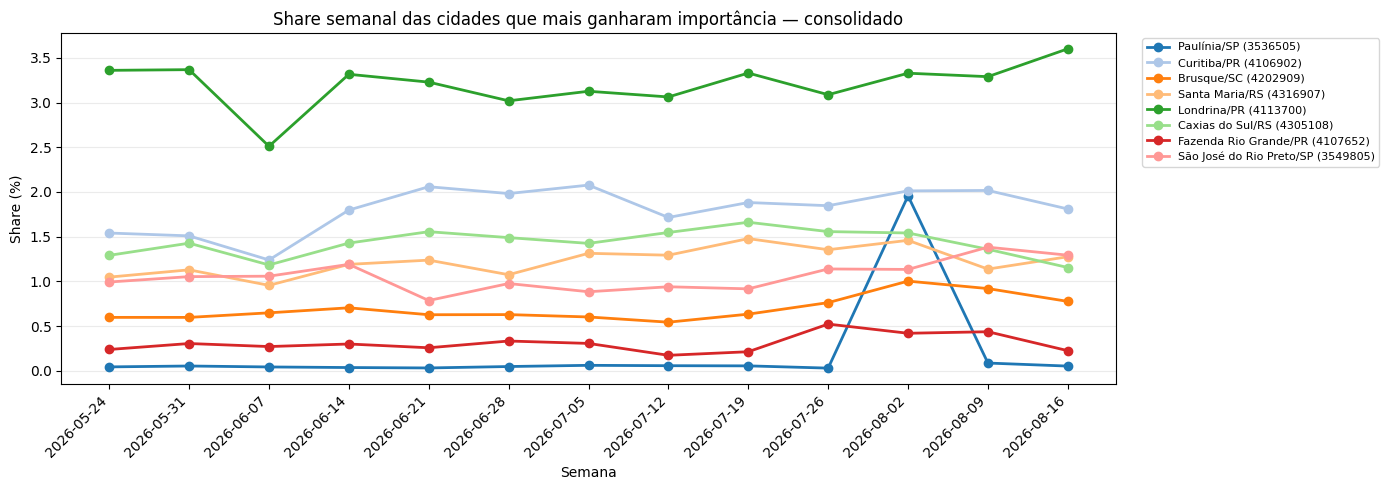


Imobiliárias — consolidado
early: ['2026-05-24', '2026-05-31', '2026-06-07'] | late: ['2026-07-26', '2026-08-02', '2026-08-09']
Imobiliárias com maior ganho de share — consolidado


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,5348,24,552,0.04,0.72,0.68,440,2,438,True
1,6885,0,430,0.0,0.56,0.56,6217,3,6214,True
2,2687,420,781,0.76,1.02,0.26,4,1,3,False
3,4881,5,196,0.01,0.26,0.25,2177,26,2151,False
4,51620,67,281,0.12,0.37,0.25,81,11,70,True
5,45829,82,274,0.15,0.36,0.21,59,14,45,True
6,52181,23,172,0.04,0.22,0.18,456,35,421,False
7,25753,1,107,0.0,0.14,0.14,4624,67,4557,False
8,23875,15,114,0.03,0.15,0.12,772,59,713,False
9,3419,4,93,0.01,0.12,0.11,2517,90,2427,False


Entraram no top 20 (não estavam antes):


,label,n_early,n_late,share_early_pct,share_late_pct,delta_pp,rank_early,rank_late,rank_gain,entered_top
0,5348,24,552,0.04,0.72,0.68,440,2,438,True
1,6885,0,430,0.0,0.56,0.56,6217,3,6214,True
4,51620,67,281,0.12,0.37,0.25,81,11,70,True
5,45829,82,274,0.15,0.36,0.21,59,14,45,True
11,13380,123,240,0.22,0.31,0.09,27,20,7,True
14,4094,155,282,0.28,0.37,0.09,22,10,12,True


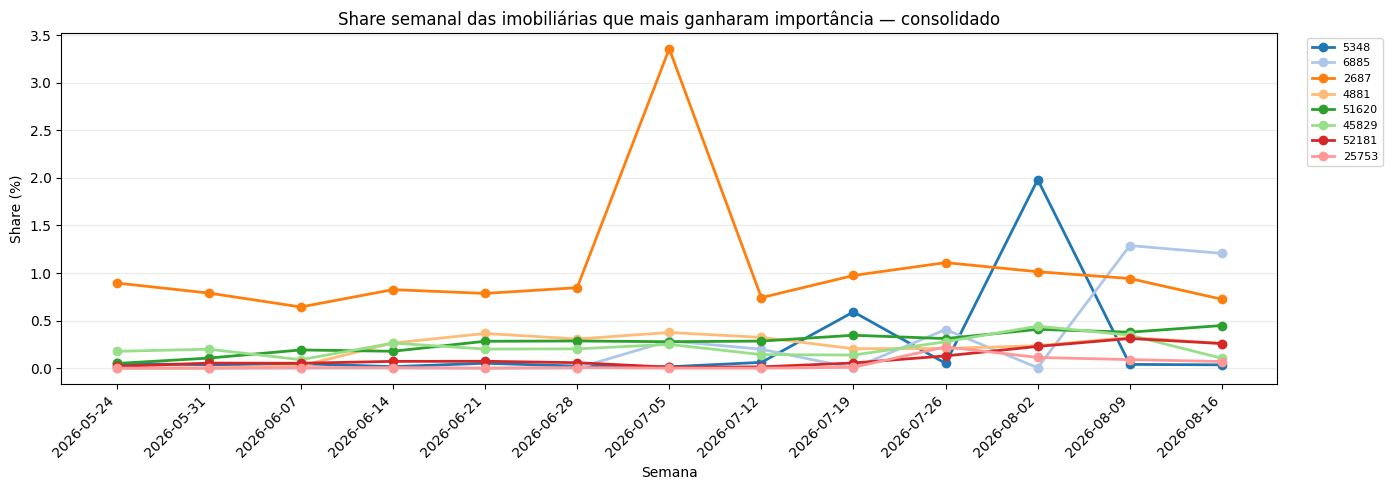

In [46]:
print("Cidades — consolidado (id_cidade_ibge)")
weeks_ok = valid_weeks(df_city)
early_weeks, late_weeks = compare_windows(weeks_ok)
print(f"early: {early_weeks} | late: {late_weeks}")
shift_city_all = share_shift_table(df_city, CITY_COL, early_weeks, late_weeks, city_label)
show_shift(shift_city_all, "Cidades com maior ganho de share — consolidado")
plot_share_lines(
    weekly_share_table(df_city, CITY_COL),
    shift_city_all.head(8)["entity"].tolist(),
    title="Share semanal das cidades que mais ganharam importância — consolidado",
    label_fn=city_label,
)

print("\nImobiliárias — consolidado")
weeks_ok_ag = valid_weeks(df_agency)
early_weeks_ag, late_weeks_ag = compare_windows(weeks_ok_ag)
print(f"early: {early_weeks_ag} | late: {late_weeks_ag}")
shift_ag_all = share_shift_table(df_agency, AGENCY_COL, early_weeks_ag, late_weeks_ag, label_agency)
show_shift(shift_ag_all, "Imobiliárias com maior ganho de share — consolidado")

plot_share_lines(
    weekly_share_table(df_agency, AGENCY_COL),
    shift_ag_all.head(8)["entity"].tolist(),
    title="Share semanal das imobiliárias que mais ganharam importância — consolidado",
    label_fn=label_agency,
)